# BioRob Phase 1C — Final Organized Synchronizer

This notebook runs **Phase 1C synchronization** after Phase 1A + Phase 1B.

Expected input after Phase 1B:
- `Sub-*/cleaned_phase1B/*.csv` if you saved Phase 1B separately, or
- `Sub-*/cleaned/*.csv` if Phase 1B overwrote Phase 1A files.

Main fixes in this version:
1. Scans **all subjects**, not only one subject.
2. Keeps `subject_id`, `task`, and `trial` in synchronized outputs.
3. Validates `subject_id` against `Sub-*` folder.
4. Validates `task` and `trial` against filename, e.g., `T516 -> task=5, trial=16`.
5. Estimates sampling rate separately for EEG, EMG, and ET only from rows where each modality exists.
6. Avoids using filled ET validity zeros to estimate ET sampling rate.
7. Saves synchronized files and JSON logs in each subject folder.


In [13]:
# ============================================================
# CELL 1 — Configuration
# This cell defines paths and run switches.
# ============================================================

from pathlib import Path

ROOT_DIR = Path("/home/tsultan1/BioRob/Human Subject Data")

# If you used the safer Phase 1B version, files are here:
PREFERRED_INPUT_DIRNAME = "cleaned_phase1B"

# If your Phase 1B overwrote Phase 1A files, files are here:
FALLBACK_INPUT_DIRNAME = "cleaned"

# Phase 1C output folder will be created inside each input folder:
# Example:
#   Sub-1/cleaned_phase1B/synchronized_proper_lite_union_v3/
# or
#   Sub-1/cleaned/synchronized_proper_lite_union_v3/
OUTPUT_DIRNAME = "synchronized_proper_lite_union_v3"

# Safety checks
STRICT_SUBJECT_FOLDER_CHECK = True   # True = skip if CSV subject_id != folder Sub-*
STOP_ON_ERROR = False                # False = continue batch and write error in summary




# Run switches
RUN_INPUT_AUDIT = True
RUN_ONE_FILE_FIRST = False
RUN_ALL_SUBJECTS = True

# Synchronization settings
GRID_MODE = "fixed"
FIXED_HZ = 250
SPAN_MODE = "all"                    # "all"=union span, "overlap"=only common overlap
FLOAT_DECIMALS = 4

print("ROOT_DIR:", ROOT_DIR)
print("Preferred input folder:", PREFERRED_INPUT_DIRNAME)
print("Fallback input folder :", FALLBACK_INPUT_DIRNAME)
print("Output folder name    :", OUTPUT_DIRNAME)
print("STRICT_SUBJECT_FOLDER_CHECK:", STRICT_SUBJECT_FOLDER_CHECK)
print("RUN_ALL_SUBJECTS:", RUN_ALL_SUBJECTS)


ROOT_DIR: /home/tsultan1/BioRob/Human Subject Data
Preferred input folder: cleaned_phase1B
Fallback input folder : cleaned
Output folder name    : synchronized_proper_lite_union_v3
STRICT_SUBJECT_FOLDER_CHECK: True
RUN_ALL_SUBJECTS: True


In [14]:
# ============================================================
# CELL 2 — Imports and global schema
# This cell defines the expected Phase 1B schema.
# ============================================================

from __future__ import annotations

import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from scipy import signal
from scipy.interpolate import interp1d

warnings.filterwarnings("ignore")

META_COLS = ["subject_id", "task", "trial", "Timestamp_seconds"]

EEG_COLS = [f"Ch{i}" for i in range(1, 9)]

EMG_COLS = [f"Ch{i} EMG raw" for i in range(1, 5)]

ET_COLS = [
    "ET_GazeLeftx", "ET_GazeLefty",
    "ET_GazeRightx", "ET_GazeRighty",
    "ET_PupilLeft", "ET_PupilRight",
    "ET_ValidityLeftEye", "ET_ValidityRightEye",
    "ET_Blink", "ET_Fixation", "ET_Worn",
    "ET_DistanceLeft", "ET_DistanceRight",
    "ET_GyroX", "ET_GyroY", "ET_GyroZ",
    "ET_AccX", "ET_AccY", "ET_AccZ",
    "ET_HeadRotationPitch", "ET_HeadRotationYaw", "ET_HeadRotationRoll",
]

# ET core columns are used to detect true ET sample rows.
# Do NOT use ET_Validity/Blink/Fixation/Worn for ET row detection,
# because Phase 1B may fill those columns with zeros for all rows.
ET_CORE_COLS = [
    "ET_GazeLeftx", "ET_GazeLefty",
    "ET_GazeRightx", "ET_GazeRighty",
    "ET_PupilLeft", "ET_PupilRight",
    "ET_DistanceLeft", "ET_DistanceRight",
    "ET_GyroX", "ET_GyroY", "ET_GyroZ",
    "ET_AccX", "ET_AccY", "ET_AccZ",
    "ET_HeadRotationPitch", "ET_HeadRotationYaw", "ET_HeadRotationRoll",
]

ET_DISCRETE_COLS = {
    "ET_ValidityLeftEye", "ET_ValidityRightEye",
    "ET_Blink", "ET_Fixation", "ET_Worn",
}

CANONICAL_PHASE1B_COLS = META_COLS + EEG_COLS + EMG_COLS + ET_COLS

print("Expected canonical Phase 1B columns:", len(CANONICAL_PHASE1B_COLS))
print(CANONICAL_PHASE1B_COLS)


Expected canonical Phase 1B columns: 38
['subject_id', 'task', 'trial', 'Timestamp_seconds', 'Ch1', 'Ch2', 'Ch3', 'Ch4', 'Ch5', 'Ch6', 'Ch7', 'Ch8', 'Ch1 EMG raw', 'Ch2 EMG raw', 'Ch3 EMG raw', 'Ch4 EMG raw', 'ET_GazeLeftx', 'ET_GazeLefty', 'ET_GazeRightx', 'ET_GazeRighty', 'ET_PupilLeft', 'ET_PupilRight', 'ET_ValidityLeftEye', 'ET_ValidityRightEye', 'ET_Blink', 'ET_Fixation', 'ET_Worn', 'ET_DistanceLeft', 'ET_DistanceRight', 'ET_GyroX', 'ET_GyroY', 'ET_GyroZ', 'ET_AccX', 'ET_AccY', 'ET_AccZ', 'ET_HeadRotationPitch', 'ET_HeadRotationYaw', 'ET_HeadRotationRoll']


In [ ]:
# ============================================================
# CELL 3 — Discover all subject input folders
# This cell finds Sub-* folders and chooses cleaned_phase1B if available,
# otherwise cleaned if Phase 1B overwrote the Phase 1A output.
# ============================================================

def subject_number(sub_dir: Path) -> int:
    m = re.match(r"Sub-(\d+)$", sub_dir.name, flags=re.IGNORECASE)
    return int(m.group(1)) if m else 10**9

def choose_input_dir(sub_dir: Path) -> Path | None:
    preferred = sub_dir / PREFERRED_INPUT_DIRNAME
    fallback = sub_dir / FALLBACK_INPUT_DIRNAME

    if preferred.exists() and any(preferred.glob("*.csv")):
        return preferred

    if fallback.exists() and any(fallback.glob("*.csv")):
        return fallback

    return None

sub_dirs = sorted(
    [p for p in ROOT_DIR.glob("Sub-*") if p.is_dir()],
    key=subject_number
)

records = []
for sub_dir in sub_dirs:
    input_dir = choose_input_dir(sub_dir)
    n_csv = len(list(input_dir.glob("*.csv"))) if input_dir else 0
    records.append({
        "subject_folder": sub_dir.name,
        "input_dir": str(input_dir) if input_dir else "",
        "csv_count": n_csv,
    })

input_dir_df = pd.DataFrame(records)

print("Found subject folders:", len(sub_dirs))
display(input_dir_df)

if input_dir_df.empty or input_dir_df["csv_count"].sum() == 0:
    raise FileNotFoundError("No Phase 1B CSV files found. Check ROOT_DIR and folder names.")


In [16]:
# ============================================================
# CELL 4 — Phase 1B CSV validation helpers
# This cell checks columns, metadata, filename task/trial, and subject folder.
# ============================================================

def parse_subject_from_path(path: Path) -> int | None:
    for part in Path(path).parts:
        m = re.match(r"Sub-(\d+)$", part, flags=re.IGNORECASE)
        if m:
            return int(m.group(1))
    return None

def parse_task_trial_from_filename(path: Path) -> tuple[int | None, int | None]:
    stem = Path(path).stem
    m = re.search(r"T(\d+)", stem, flags=re.IGNORECASE)
    if not m:
        return None, None

    token = m.group(1)
    if len(token) == 1:
        return int(token), None

    # BioRob convention:
    # T516 -> task=5, trial=16
    # T116 -> task=1, trial=16
    # T12  -> task=1, trial=2
    task = int(token[0])
    trial = int(token[1:])
    return task, trial

def estimate_fs(t: np.ndarray) -> float:
    t = np.asarray(t, dtype=float)
    t = t[np.isfinite(t)]
    if len(t) < 3:
        return 0.0

    dt = np.diff(t)
    dt = dt[(dt > 0) & (dt < 1.0)]
    if len(dt) == 0:
        return 0.0

    return float(1.0 / np.median(dt))

def load_phase1b_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="utf-8-sig")

    if "Timestamp_seconds" not in df.columns:
        raise ValueError("Missing Timestamp_seconds. Phase 1C must use Phase 1B output.")

    # Coerce all expected numeric columns that exist.
    for c in CANONICAL_PHASE1B_COLS:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["Timestamp_seconds"])
    df = df.sort_values("Timestamp_seconds").drop_duplicates("Timestamp_seconds")
    df = df.reset_index(drop=True)
    return df

def validate_phase1b_file(path: Path, df: pd.DataFrame, strict_subject: bool = True) -> tuple[list[str], list[str]]:
    errors = []
    warns = []

    missing = [c for c in CANONICAL_PHASE1B_COLS if c not in df.columns]
    if missing:
        errors.append(f"Missing required Phase 1B columns: {missing}")

    extra = [c for c in df.columns if c not in CANONICAL_PHASE1B_COLS]
    if extra:
        warns.append(f"Extra columns found and ignored/kept if needed: {extra}")

    for c in ["subject_id", "task", "trial"]:
        if c in df.columns:
            vals = sorted(pd.unique(df[c].dropna()))
            if len(vals) != 1:
                errors.append(f"{c} is not constant inside file. Values={vals[:20]}")

    folder_subject = parse_subject_from_path(path)
    if folder_subject is not None and "subject_id" in df.columns and df["subject_id"].notna().any():
        csv_subject = int(df["subject_id"].dropna().iloc[0])
        if csv_subject != folder_subject:
            msg = f"Subject mismatch: folder Sub-{folder_subject}, CSV subject_id={csv_subject}"
            if strict_subject:
                errors.append(msg)
            else:
                warns.append(msg)

    filename_task, filename_trial = parse_task_trial_from_filename(path)

    if filename_task is not None and "task" in df.columns and df["task"].notna().any():
        csv_task = int(df["task"].dropna().iloc[0])
        if csv_task != filename_task:
            errors.append(f"Task mismatch: filename says task={filename_task}, CSV task={csv_task}")

    if filename_trial is not None and "trial" in df.columns and df["trial"].notna().any():
        csv_trial = int(df["trial"].dropna().iloc[0])
        if csv_trial != filename_trial:
            errors.append(f"Trial mismatch: filename says trial={filename_trial}, CSV trial={csv_trial}")

    t = df["Timestamp_seconds"].to_numpy(dtype=float)
    if len(t) < 10:
        errors.append("Too few timestamp rows.")
    if not np.all(np.diff(t) > 0):
        errors.append("Timestamp_seconds is not strictly increasing after sorting/deduplication.")

    return errors, warns


In [ ]:
# ============================================================
# CELL 5 — Input audit before synchronization
# This cell checks every Phase 1B CSV before Phase 1C.
# ============================================================

def audit_phase1b_inputs(max_files_to_print: int = 20) -> pd.DataFrame:
    rows = []

    for rec in records:
        input_dir = Path(rec["input_dir"]) if rec["input_dir"] else None
        if input_dir is None or not input_dir.exists():
            continue

        for csv_path in sorted(input_dir.glob("*.csv")):
            if "_synchronized" in csv_path.name.lower():
                continue

            try:
                df = load_phase1b_csv(csv_path)
                errors, warns = validate_phase1b_file(
                    csv_path,
                    df,
                    strict_subject=STRICT_SUBJECT_FOLDER_CHECK,
                )

                row = {
                    "file": str(csv_path),
                    "subject_folder": csv_path.parent.parent.name,
                    "csv_subject_id": int(df["subject_id"].dropna().iloc[0]) if "subject_id" in df.columns and df["subject_id"].notna().any() else np.nan,
                    "task": int(df["task"].dropna().iloc[0]) if "task" in df.columns and df["task"].notna().any() else np.nan,
                    "trial": int(df["trial"].dropna().iloc[0]) if "trial" in df.columns and df["trial"].notna().any() else np.nan,
                    "rows": len(df),
                    "n_cols": len(df.columns),
                    "status": "PASS" if not errors else "FAIL",
                    "errors": " | ".join(errors),
                    "warnings": " | ".join(warns),
                }
            except Exception as e:
                row = {
                    "file": str(csv_path),
                    "subject_folder": csv_path.parent.parent.name,
                    "csv_subject_id": np.nan,
                    "task": np.nan,
                    "trial": np.nan,
                    "rows": np.nan,
                    "n_cols": np.nan,
                    "status": "FAIL",
                    "errors": str(e),
                    "warnings": "",
                }

            rows.append(row)

    audit_df = pd.DataFrame(rows)

    audit_out = ROOT_DIR / "_audit_phase1C_synchronizer"
    audit_out.mkdir(parents=True, exist_ok=True)
    audit_csv = audit_out / "phase1C_input_audit.csv"
    audit_df.to_csv(audit_csv, index=False)

    print("Audit saved to:", audit_csv)
    print("Files checked:", len(audit_df))

    if len(audit_df):
        print("\nStatus counts:")
        print(audit_df["status"].value_counts(dropna=False))

        fail_df = audit_df[audit_df["status"] == "FAIL"]
        if len(fail_df):
            print("\n❌ Failed files:")
            display(fail_df.head(max_files_to_print))
        else:
            print("\n✅ All Phase 1B input files passed the Phase 1C pre-check.")

    return audit_df

if RUN_INPUT_AUDIT:
    audit_df = audit_phase1b_inputs()


In [18]:
# ============================================================
# CELL 6 — Synchronization utility functions
# This cell contains filtering, lag estimation, grid generation, and interpolation.
# ============================================================

# Cross-correlation parameters
CROSS_FS = 1000
XCORR_MIN_SEC = 6.0
XCORR_WIN_SEC = 12.0
NWIN_BINS = 5
NWIN_SELECT = 3
MIN_ACCEPTED = 2

# Lag-estimation filters
EEG_BP = (1.0, 40.0)
EMG_ENV_LP = 10.0
ET_VEL_BP = (0.5, 10.0)
BP_ORDER = 3

# Anti-aliasing for fixed 250 Hz grid
AA_ENABLE = True
AA_ORDER = 8
AA_MARGIN = 0.45
AA_TOL = 1.05

# Lag guards
EMGEEG_LAG_SEARCH_MAX_MS = 200.0
EMGEEG_LAG_ABS_REJECT_MS = 150.0
BOUNDARY_HIT_FRACTION = 0.90
AGREE_TOL_MS = 30.0
FALLBACK_MAX_ABS_MS = 50.0
EMG_EEG_PRIOR_MS = -28.0
PRIOR_STRENGTH = 0.6

ET_XCORR_MIN_PR = 8.0
ET_XCORR_MAX_ABS_MS = 60.0
ET_REVERT_MARGIN = 0.007

TAPER_WINDOWS = True
NAN_INTERP_FOR_CORR = True
SCALE_EMG_TO_uV = False

GRID_STEP_MS = 1000.0 / FIXED_HZ

def split_modalities(df: pd.DataFrame):
    """
    Create separate modality tables.

    Important:
    EEG/EMG/ET are not sampled on the same original rows in Phase 1B.
    So we keep only rows where each modality has real values.
    For ET, use ET_CORE_COLS only, not validity/blink columns filled with zeros.
    """

    eeg_cols = [c for c in EEG_COLS if c in df.columns]
    emg_cols = [c for c in EMG_COLS if c in df.columns]
    et_cols = [c for c in ET_COLS if c in df.columns]

    def make_segment(cols, mask_cols=None):
        if not cols:
            return df.iloc[0:0].copy()

        if mask_cols is None:
            mask_cols = cols

        mask_cols = [c for c in mask_cols if c in df.columns]
        if not mask_cols:
            mask_cols = cols

        mask = df[mask_cols].apply(pd.to_numeric, errors="coerce").notna().any(axis=1)
        seg = df.loc[mask, ["Timestamp_seconds"] + cols].copy()
        seg = seg.dropna(subset=["Timestamp_seconds"])
        seg = seg.sort_values("Timestamp_seconds").drop_duplicates("Timestamp_seconds")
        seg = seg.reset_index(drop=True)
        return seg

    emg = make_segment(emg_cols)
    eeg = make_segment(eeg_cols)
    et = make_segment(et_cols, mask_cols=ET_CORE_COLS)

    return emg, eeg, et, emg_cols, eeg_cols, et_cols

def _safe_filtfilt(b, a, x):
    try:
        if len(x) < max(15, 3 * max(len(a), len(b))):
            return x
        return signal.filtfilt(b, a, x)
    except Exception:
        return x

def _butter_band(x, fs, f1, f2, order=BP_ORDER):
    try:
        ny = fs / 2.0
        if np.isfinite(fs) and 0 < f1 < f2 < ny:
            b, a = signal.butter(order, [f1 / ny, f2 / ny], btype="band")
            return _safe_filtfilt(b, a, x)
    except Exception:
        pass
    return x

def _butter_lp(x, fs, fc, order=BP_ORDER):
    try:
        ny = fs / 2.0
        if np.isfinite(fs) and 0 < fc < ny:
            b, a = signal.butter(order, fc / ny, btype="low")
            return _safe_filtfilt(b, a, x)
    except Exception:
        pass
    return x

def _aa_lowpass(y, fs_native, target_fs):
    y = np.asarray(y, dtype=float)
    try:
        cutoff = min(0.49, AA_MARGIN) * (target_fs / 2.0)
        ny = fs_native / 2.0
        if not (0 < cutoff < ny):
            return y
        b, a = signal.butter(AA_ORDER, cutoff / ny, btype="low")
        return _safe_filtfilt(b, a, y)
    except Exception:
        return y

def _interp_vec(t_src, y_src, t_grid, kind="linear"):
    t_src = np.asarray(t_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)

    m = np.isfinite(t_src) & np.isfinite(y_src)
    if m.sum() < 2:
        return np.full_like(t_grid, np.nan, dtype=float)

    t = t_src[m]
    y = y_src[m]

    order = np.argsort(t)
    t = t[order]
    y = y[order]

    _, idx = np.unique(t, return_index=True)
    t = t[idx]
    y = y[idx]

    if len(t) < 2:
        return np.full_like(t_grid, np.nan, dtype=float)

    f = interp1d(t, y, kind=kind, bounds_error=False, fill_value=np.nan)
    return f(t_grid)

def _round_to_grid_ms(lag_ms: float) -> float:
    return float(np.round(lag_ms / GRID_STEP_MS) * GRID_STEP_MS)

def _overlap_limits(t1, t2):
    return max(np.nanmin(t1), np.nanmin(t2)), min(np.nanmax(t1), np.nanmax(t2))

def _pick_energy_windows(t, x, ov_start, ov_end, n_bins=NWIN_BINS, n_select=NWIN_SELECT, win_sec=XCORR_WIN_SEC):
    if not np.isfinite(ov_start) or not np.isfinite(ov_end) or (ov_end - ov_start) <= 1.0:
        return []

    if ov_end - ov_start <= win_sec + 1.0:
        return [(max(ov_start, ov_start + 0.1), min(ov_end, ov_end - 0.1))]

    edges = np.linspace(ov_start, ov_end, n_bins + 1)
    scored = []

    for i in range(n_bins):
        a = edges[i]
        b = edges[i + 1]
        mid = (a + b) / 2.0
        aa = max(ov_start, mid - win_sec / 2.0)
        bb = min(ov_end, mid + win_sec / 2.0)
        m = (t >= aa) & (t <= bb) & np.isfinite(x)
        score = np.nanvar(x[m]) if m.sum() > 5 else -np.inf
        scored.append((score, aa, bb))

    scored = sorted(scored, reverse=True)[:n_select]
    return [(a, b) for score, a, b in scored if np.isfinite(score)]

def _prep_for_corr(t, x, fs, a, b):
    if b - a < XCORR_MIN_SEC:
        return None, None

    grid = np.arange(a, b, 1.0 / fs)
    y = _interp_vec(t, x, grid, kind="linear")

    if np.isfinite(y).sum() < 0.5 * len(y):
        return None, None

    if NAN_INTERP_FOR_CORR:
        y = pd.Series(y).interpolate(limit_direction="both").to_numpy()
    else:
        y = np.nan_to_num(y)

    y = y - np.nanmean(y)
    sd = np.nanstd(y)
    if not np.isfinite(sd) or sd < 1e-12:
        return None, None

    y = y / sd

    if TAPER_WINDOWS and len(y) > 4:
        y = y * signal.windows.hann(len(y), sym=False)

    return grid, y

def _xcorr_lag(x, y, fs, maxlag_ms):
    n = min(len(x), len(y))
    x = x[:n]
    y = y[:n]

    if n < 10:
        return np.nan, np.nan

    corr = signal.correlate(x, y, mode="full", method="fft")
    lags = signal.correlation_lags(n, n, mode="full") / fs * 1000.0

    m = np.abs(lags) <= maxlag_ms
    if not m.any():
        return np.nan, np.nan

    c = corr[m]
    l = lags[m]

    idx = np.nanargmax(np.abs(c))
    peak = np.abs(c[idx])
    med = np.nanmedian(np.abs(c)) + 1e-12

    return float(l[idx]), float(peak / med)

def _gcc_phat_lag(x, y, fs, maxlag_ms):
    n = min(len(x), len(y))
    x = x[:n]
    y = y[:n]

    if n < 10:
        return np.nan, np.nan

    nfft = 1
    while nfft < 2 * n:
        nfft *= 2

    X = np.fft.rfft(x, n=nfft)
    Y = np.fft.rfft(y, n=nfft)

    R = X * np.conj(Y)
    denom = np.abs(R)
    denom[denom < 1e-12] = 1e-12

    cc = np.fft.irfft(R / denom, n=nfft)

    max_shift = int(fs * maxlag_ms / 1000.0)
    cc = np.concatenate((cc[-max_shift:], cc[:max_shift + 1]))
    shifts = np.arange(-max_shift, max_shift + 1)

    idx = np.nanargmax(np.abs(cc))
    peak = np.abs(cc[idx])
    med = np.nanmedian(np.abs(cc)) + 1e-12

    return float(shifts[idx] / fs * 1000.0), float(peak / med)

def _corr_at_specific_lag(t1, x1, t2, x2, lag_ms, fs, a, b):
    grid = np.arange(a, b, 1.0 / fs)

    y1 = _interp_vec(np.asarray(t1) - lag_ms / 1000.0, x1, grid, kind="linear")
    y2 = _interp_vec(t2, x2, grid, kind="linear")

    m = np.isfinite(y1) & np.isfinite(y2)
    if m.sum() < 10:
        return np.nan

    y1 = y1[m]
    y2 = y2[m]

    if np.std(y1) < 1e-12 or np.std(y2) < 1e-12:
        return np.nan

    return float(np.corrcoef(y1, y2)[0, 1])


In [19]:
# ============================================================
# CELL 7 — Lag estimation and interpolation functions
# This cell estimates EMG↔EEG and EEG↔ET lags, then resamples to 250 Hz.
# ============================================================

def estimate_emg_eeg_lag(emg: pd.DataFrame, eeg: pd.DataFrame, emg_cols, eeg_cols):
    if not emg_cols or not eeg_cols or len(emg) < 10 or len(eeg) < 10:
        return 0.0, np.nan, None

    t_emg_all = emg["Timestamp_seconds"].to_numpy(dtype=float)

    # Pick the most energetic EMG envelope channel.
    best_env = None
    best_t_emg = None
    best_var = -np.inf
    best_emg_ch = None

    for c in emg_cols:
        y = pd.to_numeric(emg[c], errors="coerce").to_numpy(dtype=float)
        m = np.isfinite(t_emg_all) & np.isfinite(y)
        if m.sum() < 10:
            continue

        t = t_emg_all[m]
        x = np.abs(y[m])
        fs = estimate_fs(t)
        x = _butter_lp(np.nan_to_num(x), fs, EMG_ENV_LP)

        v = np.nanvar(x)
        if v > best_var:
            best_var = v
            best_env = x
            best_t_emg = t
            best_emg_ch = c

    if best_env is None:
        return 0.0, np.nan, None

    t_eeg_all = eeg["Timestamp_seconds"].to_numpy(dtype=float)

    ov_start, ov_end = _overlap_limits(best_t_emg, t_eeg_all)
    wins = _pick_energy_windows(best_t_emg, best_env, ov_start, ov_end)

    if not wins:
        return 0.0, np.nan, None

    # Pick EEG channel with strongest correlation evidence.
    best = {"score": -np.inf, "ch": None}

    for ec in eeg_cols:
        y = pd.to_numeric(eeg[ec], errors="coerce").to_numpy(dtype=float)
        m = np.isfinite(t_eeg_all) & np.isfinite(y)
        if m.sum() < 10:
            continue

        t_eeg = t_eeg_all[m]
        x_eeg = y[m]
        fs_eeg = estimate_fs(t_eeg)
        x_eeg = _butter_band(np.nan_to_num(x_eeg), fs_eeg, EEG_BP[0], EEG_BP[1])

        prs = []
        for a, b in wins:
            _, env = _prep_for_corr(best_t_emg, best_env, CROSS_FS, a, b)
            _, eegf = _prep_for_corr(t_eeg, x_eeg, CROSS_FS, a, b)

            if env is None or eegf is None:
                continue

            _, pr = _xcorr_lag(env, eegf, CROSS_FS, EMGEEG_LAG_SEARCH_MAX_MS)
            prs.append(pr)

        if prs:
            score = float(np.median(prs))
            if score > best["score"]:
                best = {"score": score, "ch": ec}

    chosen_eeg = best["ch"]

    if chosen_eeg is None:
        lag = EMG_EEG_PRIOR_MS * PRIOR_STRENGTH
        lag = float(np.clip(lag, -FALLBACK_MAX_ABS_MS, FALLBACK_MAX_ABS_MS))
        return _round_to_grid_ms(lag), np.nan, None

    # Estimate lag with chosen EEG channel.
    y = pd.to_numeric(eeg[chosen_eeg], errors="coerce").to_numpy(dtype=float)
    m = np.isfinite(t_eeg_all) & np.isfinite(y)
    t_eeg = t_eeg_all[m]
    x_eeg = y[m]
    fs_eeg = estimate_fs(t_eeg)
    x_eeg = _butter_band(np.nan_to_num(x_eeg), fs_eeg, EEG_BP[0], EEG_BP[1])

    lags = []
    weights = []
    boundary_hits = 0

    for a, b in wins[:NWIN_SELECT]:
        _, env = _prep_for_corr(best_t_emg, best_env, CROSS_FS, a, b)
        _, eegf = _prep_for_corr(t_eeg, x_eeg, CROSS_FS, a, b)

        if env is None or eegf is None:
            continue

        lag_a, pr_a = _xcorr_lag(env, eegf, CROSS_FS, EMGEEG_LAG_SEARCH_MAX_MS)
        lag_b, pr_b = _gcc_phat_lag(env, eegf, CROSS_FS, EMGEEG_LAG_SEARCH_MAX_MS)

        if np.isfinite(lag_a) and np.isfinite(pr_a):
            lags.append(lag_a)
            weights.append(max(pr_a, 1.0))
            if abs(lag_a) > BOUNDARY_HIT_FRACTION * EMGEEG_LAG_SEARCH_MAX_MS:
                boundary_hits += 1

        if np.isfinite(lag_b) and np.isfinite(pr_b):
            if (not np.isfinite(lag_a)) or abs(lag_b - lag_a) <= AGREE_TOL_MS:
                lags.append(lag_b)
                weights.append(max(pr_b, 1.0))
                if abs(lag_b) > BOUNDARY_HIT_FRACTION * EMGEEG_LAG_SEARCH_MAX_MS:
                    boundary_hits += 1

    if len(lags) < MIN_ACCEPTED or boundary_hits > len(lags) // 2:
        lag = EMG_EEG_PRIOR_MS * PRIOR_STRENGTH
        lag = float(np.clip(lag, -FALLBACK_MAX_ABS_MS, FALLBACK_MAX_ABS_MS))
        return _round_to_grid_ms(lag), np.nan, chosen_eeg

    lags = np.asarray(lags, dtype=float)
    weights = np.asarray(weights, dtype=float)

    lag = float(np.average(lags, weights=weights))

    if abs(lag) > EMGEEG_LAG_ABS_REJECT_MS:
        lag = EMG_EEG_PRIOR_MS * PRIOR_STRENGTH

    return _round_to_grid_ms(lag), float(np.median(weights)), chosen_eeg

def _et_velocity(et: pd.DataFrame, prefer=("ET_GazeLeftx", "ET_GazeRightx", "ET_GazeLefty", "ET_GazeRighty")):
    for name in prefer:
        if name in et.columns:
            t = et["Timestamp_seconds"].to_numpy(dtype=float)
            x = pd.to_numeric(et[name], errors="coerce").to_numpy(dtype=float)

            m = np.isfinite(t) & np.isfinite(x)
            if m.sum() < 3:
                continue

            t = t[m]
            x = x[m]

            order = np.argsort(t)
            t = t[order]
            x = x[order]

            dt = np.diff(t)
            v = np.full_like(x, np.nan, dtype=float)
            good = dt > 0
            v[1:][good] = np.diff(x)[good] / dt[good]

            return t, v

    return None, None

def estimate_eeg_et_lag(eeg: pd.DataFrame, et: pd.DataFrame, eeg_ch: str | None):
    if len(eeg) < 10 or len(et) < 10 or eeg_ch is None:
        return 0.0

    t_eeg_all = eeg["Timestamp_seconds"].to_numpy(dtype=float)
    y = pd.to_numeric(eeg[eeg_ch], errors="coerce").to_numpy(dtype=float)

    m = np.isfinite(t_eeg_all) & np.isfinite(y)
    if m.sum() < 10:
        return 0.0

    t_eeg = t_eeg_all[m]
    x_eeg = y[m]
    fs_eeg = estimate_fs(t_eeg)
    x_eeg = _butter_band(np.nan_to_num(x_eeg), fs_eeg, EEG_BP[0], EEG_BP[1])

    t_et, v_et = _et_velocity(et)
    if t_et is None:
        return 0.0

    fs_et = estimate_fs(t_et)
    v_et = _butter_band(np.nan_to_num(v_et), fs_et, ET_VEL_BP[0], ET_VEL_BP[1])

    ov_start, ov_end = _overlap_limits(t_et, t_eeg)
    wins = _pick_energy_windows(t_et, v_et, ov_start, ov_end, n_bins=3, n_select=1, win_sec=XCORR_WIN_SEC)

    if not wins:
        return 0.0

    a, b = wins[0]

    _, vh = _prep_for_corr(t_et, v_et, CROSS_FS, a, b)
    _, eh = _prep_for_corr(t_eeg, x_eeg, CROSS_FS, a, b)

    if vh is None or eh is None:
        return 0.0

    lag_ms, pr = _xcorr_lag(vh, eh, CROSS_FS, ET_XCORR_MAX_ABS_MS)

    if (
        not np.isfinite(lag_ms)
        or not np.isfinite(pr)
        or pr < ET_XCORR_MIN_PR
        or abs(lag_ms) > ET_XCORR_MAX_ABS_MS
    ):
        return 0.0

    corr0 = _corr_at_specific_lag(t_et, v_et, t_eeg, x_eeg, 0.0, CROSS_FS, a, b)
    corrlag = _corr_at_specific_lag(t_et, v_et, t_eeg, x_eeg, lag_ms, CROSS_FS, a, b)

    if (
        not np.isfinite(corr0)
        or not np.isfinite(corrlag)
        or corrlag <= corr0 + ET_REVERT_MARGIN
    ):
        return 0.0

    return _round_to_grid_ms(lag_ms)

def make_time_grid(emg: pd.DataFrame, eeg: pd.DataFrame, et: pd.DataFrame) -> np.ndarray:
    spans = []

    for seg in (emg, eeg, et):
        if len(seg):
            t = seg["Timestamp_seconds"].to_numpy(dtype=float)
            spans.append((float(np.nanmin(t)), float(np.nanmax(t))))

    if not spans:
        return np.array([])

    if SPAN_MODE == "overlap":
        tmin = max(s for s, _ in spans)
        tmax = min(e for _, e in spans)
    else:
        tmin = min(s for s, _ in spans)
        tmax = max(e for _, e in spans)

    if not np.isfinite(tmin) or not np.isfinite(tmax) or tmax <= tmin:
        return np.array([])

    if GRID_MODE == "fixed":
        n = int(np.floor((tmax - tmin) * FIXED_HZ)) + 1
        return tmin + np.arange(n) / FIXED_HZ

    # Native fallback: use EEG grid if available, then EMG, then ET.
    if len(eeg):
        return eeg["Timestamp_seconds"].to_numpy(dtype=float)
    if len(emg):
        return emg["Timestamp_seconds"].to_numpy(dtype=float)
    if len(et):
        return et["Timestamp_seconds"].to_numpy(dtype=float)

    return np.array([])

def apply_shift_and_interp(seg: pd.DataFrame, cols, t_grid, lag_ms=0.0, kind="linear"):
    if len(seg) == 0 or len(t_grid) == 0 or not cols:
        return {}, []

    out = {}
    aa_list = []
    t0 = seg["Timestamp_seconds"].to_numpy(dtype=float)

    for c in cols:
        if c not in seg.columns:
            continue

        y = pd.to_numeric(seg[c], errors="coerce").to_numpy(dtype=float)
        m = np.isfinite(t0) & np.isfinite(y)

        if m.sum() < 2:
            out[c] = np.full_like(t_grid, np.nan, dtype=float)
            continue

        tt = t0[m]
        yy = y[m]

        order = np.argsort(tt)
        tt = tt[order]
        yy = yy[order]

        _, idx = np.unique(tt, return_index=True)
        tt = tt[idx]
        yy = yy[idx]

        fs_native = estimate_fs(tt)

        did_aa = False
        if (
            AA_ENABLE
            and GRID_MODE == "fixed"
            and fs_native > FIXED_HZ * AA_TOL
            and c not in ET_DISCRETE_COLS
        ):
            yy = _aa_lowpass(yy, fs_native, FIXED_HZ)
            did_aa = True

        if SCALE_EMG_TO_uV and "EMG" in c:
            yy = yy * 1000.0

        interp_kind = "nearest" if c in ET_DISCRETE_COLS else kind
        out[c] = _interp_vec(tt - lag_ms / 1000.0, yy, t_grid, kind=interp_kind)

        # For discrete ET validity/event columns, outside ET span should be explicit 0.
        if c in ET_DISCRETE_COLS:
            out[c] = np.nan_to_num(out[c], nan=0.0)

        if did_aa:
            aa_list.append(c)

    return out, aa_list


In [20]:
# ============================================================
# CELL 8 — Process one file
# This cell synchronizes one Phase 1B CSV and saves CSV + JSON log.
# ============================================================

def process_one_file(csv_path: Path, out_dir: Path) -> dict:
    csv_path = Path(csv_path)
    out_dir = Path(out_dir)

    print("\n" + "=" * 80)
    print("Processing:", csv_path)
    print("=" * 80)

    df = load_phase1b_csv(csv_path)
    errors, warns = validate_phase1b_file(
        csv_path,
        df,
        strict_subject=STRICT_SUBJECT_FOLDER_CHECK,
    )

    if errors:
        raise ValueError(" | ".join(errors))

    if warns:
        for w in warns:
            print("⚠️", w)

    subject_id = int(df["subject_id"].dropna().iloc[0])
    task = int(df["task"].dropna().iloc[0])
    trial = int(df["trial"].dropna().iloc[0])

    emg, eeg, et, emg_cols, eeg_cols, et_cols = split_modalities(df)

    fs_emg = estimate_fs(emg["Timestamp_seconds"].to_numpy(dtype=float)) if len(emg) else 0.0
    fs_eeg = estimate_fs(eeg["Timestamp_seconds"].to_numpy(dtype=float)) if len(eeg) else 0.0
    fs_et = estimate_fs(et["Timestamp_seconds"].to_numpy(dtype=float)) if len(et) else 0.0

    print(f"Metadata: subject_id={subject_id}, task={task}, trial={trial}")
    print(f"Rows: input={len(df)} | EMG={len(emg)} | EEG={len(eeg)} | ET={len(et)}")
    print(f"Estimated native fs: EMG={fs_emg:.2f} Hz | EEG={fs_eeg:.2f} Hz | ET={fs_et:.2f} Hz")

    # Estimate lags.
    emg_eeg_lag, pr_med, best_eeg_ch = estimate_emg_eeg_lag(emg, eeg, emg_cols, eeg_cols)
    eeg_et_lag = estimate_eeg_et_lag(eeg, et, best_eeg_ch)
    emg_et_lag = float(emg_eeg_lag - eeg_et_lag)

    print(f"EMG→EEG lag: {emg_eeg_lag:+.1f} ms | best EEG channel: {best_eeg_ch}")
    print(f"ET→EEG lag : {eeg_et_lag:+.1f} ms")
    print(f"EMG→ET lag : {emg_et_lag:+.1f} ms")

    # Make fixed grid.
    t_grid = make_time_grid(emg, eeg, et)
    if len(t_grid) == 0:
        raise RuntimeError("Empty synchronization grid.")

    print(f"Output grid: {len(t_grid)} rows at {FIXED_HZ} Hz")

    out = {
        "subject_id": np.full(len(t_grid), subject_id, dtype=int),
        "task": np.full(len(t_grid), task, dtype=int),
        "trial": np.full(len(t_grid), trial, dtype=int),
        "Timestamp_seconds": t_grid,
        "Timestamp_ms": t_grid * 1000.0,
    }

    aa_log = {"emg": [], "eeg": [], "et": []}

    emg_interp, aa = apply_shift_and_interp(emg, emg_cols, t_grid, lag_ms=emg_eeg_lag)
    out.update(emg_interp)
    aa_log["emg"] = aa

    eeg_interp, aa = apply_shift_and_interp(eeg, eeg_cols, t_grid, lag_ms=0.0)
    out.update(eeg_interp)
    aa_log["eeg"] = aa

    et_interp, aa = apply_shift_and_interp(et, et_cols, t_grid, lag_ms=eeg_et_lag)
    out.update(et_interp)
    aa_log["et"] = aa

    synced = pd.DataFrame(out)

    # Keep stable column order.
    out_cols = ["subject_id", "task", "trial", "Timestamp_seconds", "Timestamp_ms"]
    out_cols += EMG_COLS + EEG_COLS + ET_COLS
    out_cols = [c for c in out_cols if c in synced.columns]
    synced = synced[out_cols]

    # Drop columns that are entirely missing, but never drop metadata/time.
    protected = {"subject_id", "task", "trial", "Timestamp_seconds", "Timestamp_ms"}
    all_nan_cols = [
        c for c in synced.columns
        if c not in protected and synced[c].isna().all()
    ]
    if all_nan_cols:
        print("⚠️ Dropping all-NaN columns:", all_nan_cols)
        synced = synced.drop(columns=all_nan_cols)

    # Round float columns.
    for c in synced.select_dtypes(include=["float64", "float32"]).columns:
        synced[c] = synced[c].round(FLOAT_DECIMALS)

    out_dir.mkdir(parents=True, exist_ok=True)

    stem = csv_path.stem
    out_csv = out_dir / f"{stem}_synchronized_corrected.csv"
    out_json = out_dir / f"{stem}_synchronized_corrected.json"

    synced.to_csv(out_csv, index=False, float_format=f"%.{FLOAT_DECIMALS}f")

    log = {
        "input_file": str(csv_path.resolve()),
        "output_csv": str(out_csv.resolve()),
        "subject_id": subject_id,
        "task": task,
        "trial": trial,
        "rows_input": int(len(df)),
        "rows_emg": int(len(emg)),
        "rows_eeg": int(len(eeg)),
        "rows_et": int(len(et)),
        "grid_rows": int(len(t_grid)),
        "fs_emg": float(fs_emg),
        "fs_eeg": float(fs_eeg),
        "fs_et": float(fs_et),
        "lag_emg_eeg_ms": float(emg_eeg_lag),
        "lag_eeg_eye_ms": float(eeg_et_lag),
        "lag_emg_eye_ms": float(emg_et_lag),
        "best_eeg_channel": best_eeg_ch if best_eeg_ch is not None else "",
        "aa_applied_channels": aa_log,
        "warnings": warns,
        "notes": (
            "Phase 1C synchronized EEG, EMG, and ET to a fixed grid. "
            "Metadata subject_id/task/trial are preserved. "
            "Sampling rates are estimated per modality using finite modality rows only."
        ),
    }

    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(log, f, indent=2)

    print("Saved CSV :", out_csv)
    print("Saved JSON:", out_json)

    # Final saved-file check.
    saved = pd.read_csv(out_csv)
    meta_ok = (
        saved["subject_id"].nunique() == 1
        and int(saved["subject_id"].iloc[0]) == subject_id
        and saved["task"].nunique() == 1
        and int(saved["task"].iloc[0]) == task
        and saved["trial"].nunique() == 1
        and int(saved["trial"].iloc[0]) == trial
    )

    time_ok = saved["Timestamp_seconds"].is_monotonic_increasing

    if meta_ok and time_ok:
        print("✅ SYNCHRONIZATION APPLIED CORRECTLY")
    else:
        print("❌ SYNCHRONIZATION CHECK FAILED")
        print("meta_ok:", meta_ok, "time_ok:", time_ok)

    return {
        "filename": csv_path.name,
        "subject_id": subject_id,
        "task": task,
        "trial": trial,
        "status": "OK",
        "rows_input": len(df),
        "rows_emg": len(emg),
        "rows_eeg": len(eeg),
        "rows_et": len(et),
        "grid_rows": len(t_grid),
        "fs_emg": fs_emg,
        "fs_eeg": fs_eeg,
        "fs_et": fs_et,
        "lag_emg_eeg_ms": emg_eeg_lag,
        "lag_eeg_eye_ms": eeg_et_lag,
        "best_eeg_channel": best_eeg_ch,
        "output_csv": str(out_csv),
        "warnings": " | ".join(warns),
    }


In [21]:
# ============================================================
# CELL 9 — Run one file first
# This cell runs Phase 1C on one representative file before the full batch.
# ============================================================

def get_first_phase1b_file() -> Path:
    for rec in records:
        input_dir = Path(rec["input_dir"]) if rec["input_dir"] else None
        if input_dir is None or not input_dir.exists():
            continue

        files = sorted([
            p for p in input_dir.glob("*.csv")
            if "_synchronized" not in p.name.lower()
        ])

        if files:
            return files[0]

    raise FileNotFoundError("No Phase 1B CSV file found.")

one_file_result = None

if RUN_ONE_FILE_FIRST:
    one_file = get_first_phase1b_file()
    one_out_dir = one_file.parent / OUTPUT_DIRNAME

    print("Testing one file first:")
    print(one_file)

    one_file_result = process_one_file(one_file, one_out_dir)
    display(pd.DataFrame([one_file_result]))


In [22]:
# ============================================================
# CELL 10 — Visual check after one-file synchronization
# This cell plots EEG, EMG, and ET on the same time axis.
# ============================================================

import matplotlib.pyplot as plt

def zscore_for_plot(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(dtype=float)
    m = np.isfinite(x)
    y = np.full_like(x, np.nan, dtype=float)
    if m.sum() < 5:
        return y
    y[m] = (x[m] - np.nanmean(x[m])) / (np.nanstd(x[m]) + 1e-12)
    return y

def plot_one_synchronized_file(sync_csv: Path, seconds: float = 8.0):
    sync_csv = Path(sync_csv)
    df = pd.read_csv(sync_csv)

    t = df["Timestamp_seconds"].to_numpy(dtype=float)
    t0 = np.nanmin(t)
    keep = t <= t0 + seconds

    plt.figure(figsize=(16, 5))

    if "Ch1" in df.columns:
        plt.plot(t[keep], zscore_for_plot(df.loc[keep, "Ch1"]), label="EEG Ch1 z-score")

    if "Ch1 EMG raw" in df.columns:
        plt.plot(t[keep], zscore_for_plot(df.loc[keep, "Ch1 EMG raw"]), label="EMG Ch1 z-score")

    if "ET_GazeLeftx" in df.columns:
        plt.plot(t[keep], zscore_for_plot(df.loc[keep, "ET_GazeLeftx"]), label="ET GazeLeftx z-score")

    plt.title(f"Synchronized EEG + EMG + ET check: {sync_csv.name}")
    plt.xlabel("Time (s)")
    plt.ylabel("Z-score for visual comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

if one_file_result is not None:
    plot_one_synchronized_file(one_file_result["output_csv"], seconds=8.0)


In [ ]:
# ============================================================
# CELL 11 — Run Phase 1C for all subjects
# Change RUN_ALL_SUBJECTS=True in CELL 1 after the one-file test passes.
# ============================================================

def run_all_phase1c() -> pd.DataFrame:
    rows = []

    for rec in records:
        input_dir = Path(rec["input_dir"]) if rec["input_dir"] else None
        if input_dir is None or not input_dir.exists():
            continue

        out_dir = input_dir / OUTPUT_DIRNAME

        files = sorted([
            p for p in input_dir.glob("*.csv")
            if "_synchronized" not in p.name.lower()
        ])

        print("\n" + "#" * 90)
        print(f"Subject folder: {input_dir.parent.name}")
        print("Input dir :", input_dir)
        print("Output dir:", out_dir)
        print("Files     :", len(files))
        print("#" * 90)

        for i, csv_path in enumerate(files, start=1):
            print(f"\n[{i}/{len(files)}] {csv_path.name}")

            try:
                row = process_one_file(csv_path, out_dir)
            except Exception as e:
                print("❌ ERROR:", e)
                row = {
                    "filename": csv_path.name,
                    "subject_id": np.nan,
                    "task": np.nan,
                    "trial": np.nan,
                    "status": f"ERROR: {e}",
                    "rows_input": np.nan,
                    "rows_emg": np.nan,
                    "rows_eeg": np.nan,
                    "rows_et": np.nan,
                    "grid_rows": np.nan,
                    "fs_emg": np.nan,
                    "fs_eeg": np.nan,
                    "fs_et": np.nan,
                    "lag_emg_eeg_ms": np.nan,
                    "lag_eeg_eye_ms": np.nan,
                    "best_eeg_channel": "",
                    "output_csv": "",
                    "warnings": "",
                }

                if STOP_ON_ERROR:
                    raise

            row["input_dir"] = str(input_dir)
            row["subject_folder"] = input_dir.parent.name
            rows.append(row)

    summary_df = pd.DataFrame(rows)

    audit_out = ROOT_DIR / "_audit_phase1C_synchronizer"
    audit_out.mkdir(parents=True, exist_ok=True)

    summary_csv = audit_out / "phase1C_synchronization_summary_all_subjects.csv"
    summary_df.to_csv(summary_csv, index=False)

    print("\nSummary saved to:", summary_csv)

    if len(summary_df):
        print("\nStatus counts:")
        print(summary_df["status"].value_counts(dropna=False))

        print("\nSampling-rate summary:")
        display(summary_df[["fs_emg", "fs_eeg", "fs_et"]].describe())

        print("\nFirst rows:")
        display(summary_df.head())

    return summary_df

summary_df = None

if RUN_ALL_SUBJECTS:
    summary_df = run_all_phase1c()
else:
    print("RUN_ALL_SUBJECTS is False. After one-file test passes, set it to True in CELL 1 and rerun.")


In [25]:
# ============================================================
# CELL 12 — Verify synchronized outputs
# This cell checks all saved synchronized CSV files.
# ============================================================

def verify_synchronized_outputs() -> pd.DataFrame:
    rows = []

    for rec in records:
        input_dir = Path(rec["input_dir"]) if rec["input_dir"] else None
        if input_dir is None or not input_dir.exists():
            continue

        sync_dir = input_dir / OUTPUT_DIRNAME
        if not sync_dir.exists():
            continue

        for sync_csv in sorted(sync_dir.glob("*_synchronized_corrected.csv")):
            try:
                df = pd.read_csv(sync_csv)

                required = ["subject_id", "task", "trial", "Timestamp_seconds", "Timestamp_ms"]
                missing = [c for c in required if c not in df.columns]

                row = {
                    "file": str(sync_csv),
                    "rows": len(df),
                    "cols": len(df.columns),
                    "subject_id_nunique": df["subject_id"].nunique() if "subject_id" in df.columns else np.nan,
                    "task_nunique": df["task"].nunique() if "task" in df.columns else np.nan,
                    "trial_nunique": df["trial"].nunique() if "trial" in df.columns else np.nan,
                    "time_monotonic": bool(df["Timestamp_seconds"].is_monotonic_increasing) if "Timestamp_seconds" in df.columns else False,
                    "missing_required": missing,
                    "status": "PASS" if not missing and df["Timestamp_seconds"].is_monotonic_increasing else "FAIL",
                }
            except Exception as e:
                row = {
                    "file": str(sync_csv),
                    "rows": np.nan,
                    "cols": np.nan,
                    "subject_id_nunique": np.nan,
                    "task_nunique": np.nan,
                    "trial_nunique": np.nan,
                    "time_monotonic": False,
                    "missing_required": str(e),
                    "status": "FAIL",
                }

            rows.append(row)

    verify_df = pd.DataFrame(rows)

    audit_out = ROOT_DIR / "_audit_phase1C_synchronizer"
    audit_out.mkdir(parents=True, exist_ok=True)

    verify_csv = audit_out / "phase1C_output_verification.csv"
    verify_df.to_csv(verify_csv, index=False)

    print("Verification saved to:", verify_csv)

    if len(verify_df):
        print("Output files checked:", len(verify_df))
        print(verify_df["status"].value_counts(dropna=False))

        fail_df = verify_df[verify_df["status"] == "FAIL"]
        if len(fail_df):
            print("\n❌ Failed synchronized files:")
            display(fail_df.head(20))
        else:
            print("\n✅ All synchronized outputs passed basic verification.")

    return verify_df

verify_df = verify_synchronized_outputs()


Verification saved to: /home/tsultan1/BioRob/Human Subject Data/_audit_phase1C_synchronizer/phase1C_output_verification.csv
Output files checked: 1552
status
PASS    1552
Name: count, dtype: int64

✅ All synchronized outputs passed basic verification.


Synchronized CSV: /home/tsultan1/BioRob/Human Subject Data/Sub-23/cleaned/synchronized_proper_lite_union_v3/082_T11_synchronized_corrected.csv
Exists: True

Shape: (2054, 39)

Columns:
 - subject_id
 - task
 - trial
 - Timestamp_seconds
 - Timestamp_ms
 - Ch1 EMG raw
 - Ch2 EMG raw
 - Ch3 EMG raw
 - Ch4 EMG raw
 - Ch1
 - Ch2
 - Ch3
 - Ch4
 - Ch5
 - Ch6
 - Ch7
 - Ch8
 - ET_GazeLeftx
 - ET_GazeLefty
 - ET_GazeRightx
 - ET_GazeRighty
 - ET_PupilLeft
 - ET_PupilRight
 - ET_ValidityLeftEye
 - ET_ValidityRightEye
 - ET_Blink
 - ET_Fixation
 - ET_Worn
 - ET_DistanceLeft
 - ET_DistanceRight
 - ET_GyroX
 - ET_GyroY
 - ET_GyroZ
 - ET_AccX
 - ET_AccY
 - ET_AccZ
 - ET_HeadRotationPitch
 - ET_HeadRotationYaw
 - ET_HeadRotationRoll

Metadata check:
subject_id: [23]
task      : [1]
trial     : [1]

Time-grid check:
duration seconds: 8.212
median dt       : 0.004
estimated fs    : 250.0 Hz
✅ Output grid looks close to 250 Hz.

Lag JSON:
fs_emg: 500.0000000000551
fs_eeg: 500.8012643376174
fs_et: 200.00

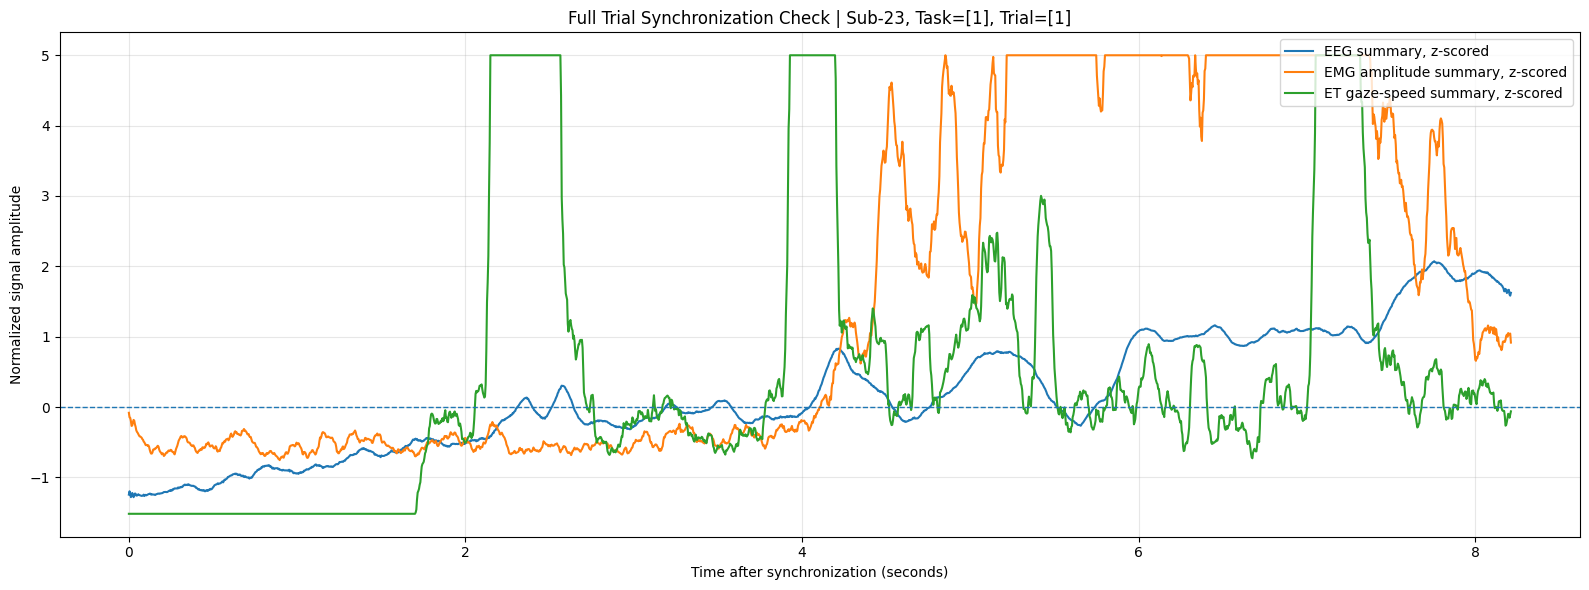

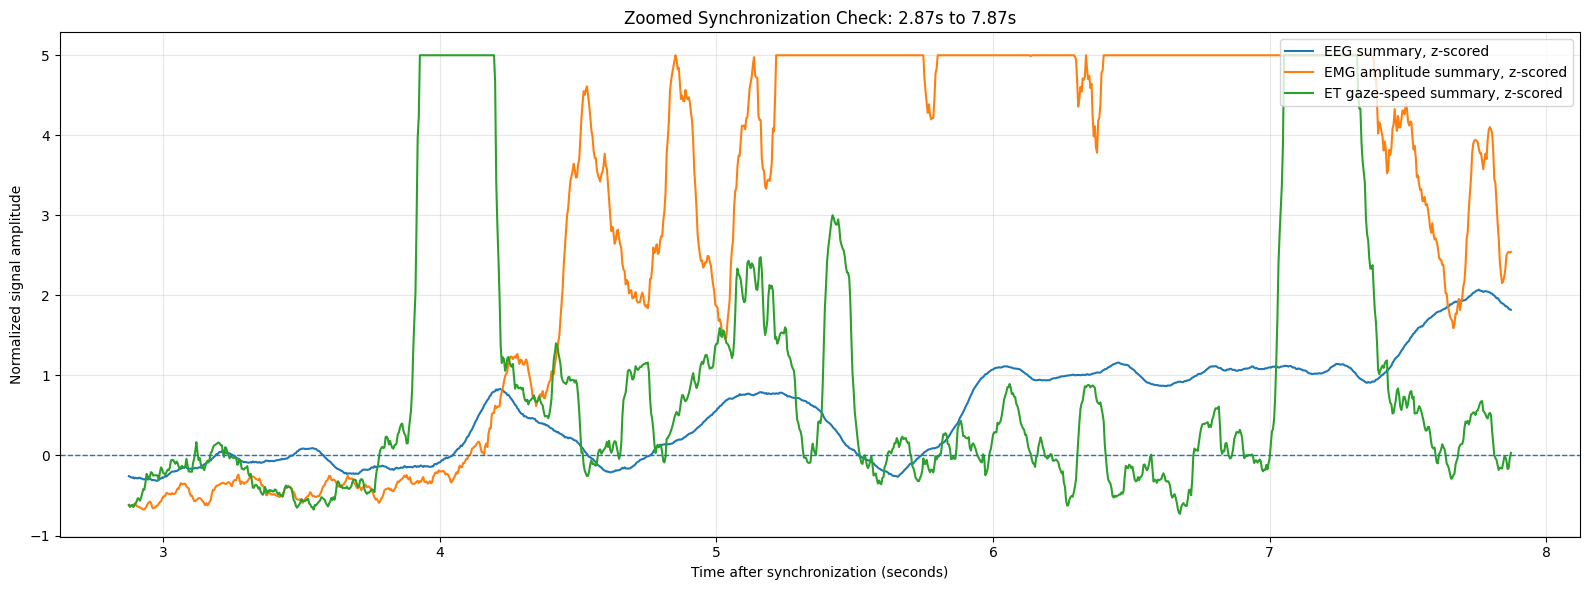

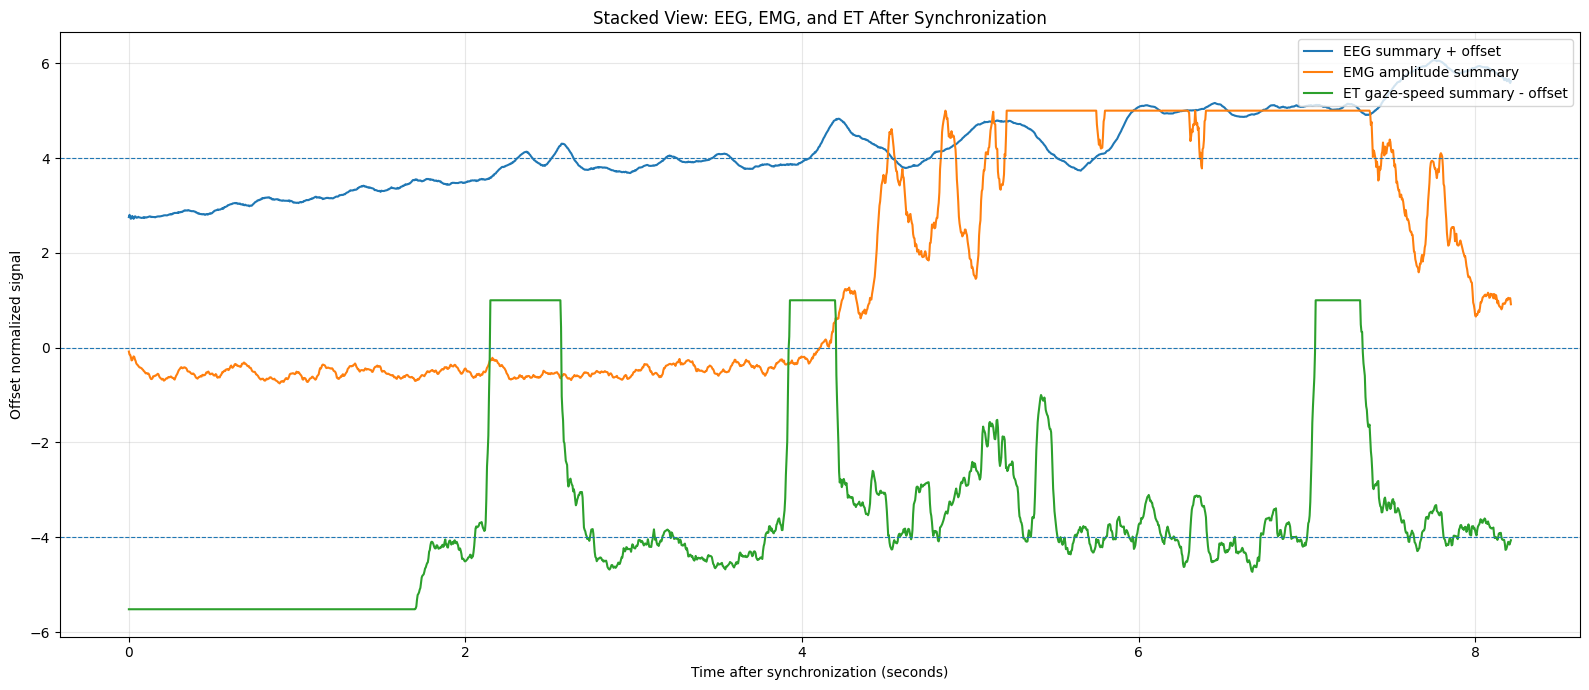


✅ Synchronization plot completed.

How to interpret:
 - All three signals are plotted on the same synchronized 250 Hz time axis.
 - EMG and ET activity should occur in a reasonable similar time region.
 - EEG may look noisier or less sharply aligned; that is normal.
 - Small lag values such as 0–30 ms are usually acceptable.
 - Large visible shifts, flat signals, or missing modality traces need rechecking.


In [28]:
# ============================================================
# EXTRA CHECK — Plot one synchronized trial: EEG + EMG + ET
# Compatible with your Phase 1C output column names:
# EEG: Ch1 ... Ch8
# EMG: Ch1 EMG raw ... Ch4 EMG raw
# ET : ET_GazeLeftx/y, ET_GazeRightx/y
# ============================================================

from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Choose one synchronized Phase 1C output file
# ------------------------------------------------------------
SYNC_CSV = Path(
    "/home/tsultan1/BioRob/Human Subject Data/Sub-23/cleaned/"
    "synchronized_proper_lite_union_v3/082_T11_synchronized_corrected.csv"
)

SYNC_JSON = SYNC_CSV.with_suffix(".json")

print("=" * 90)
print("Synchronized CSV:", SYNC_CSV)
print("Exists:", SYNC_CSV.exists())
print("=" * 90)

if not SYNC_CSV.exists():
    raise FileNotFoundError(f"File not found: {SYNC_CSV}")

df = pd.read_csv(SYNC_CSV)

print("\nShape:", df.shape)
print("\nColumns:")
for c in df.columns:
    print(" -", c)

# ------------------------------------------------------------
# 2) Basic metadata and time-grid check
# ------------------------------------------------------------
required_meta = ["subject_id", "task", "trial", "Timestamp_seconds"]
missing_meta = [c for c in required_meta if c not in df.columns]

if missing_meta:
    raise ValueError(f"Missing required metadata/time columns: {missing_meta}")

subject_values = df["subject_id"].dropna().unique()
task_values = df["task"].dropna().unique()
trial_values = df["trial"].dropna().unique()

print("\nMetadata check:")
print("subject_id:", subject_values)
print("task      :", task_values)
print("trial     :", trial_values)

if len(subject_values) != 1:
    print("⚠️ Multiple subject_id values found. Check metadata.")
if len(task_values) != 1:
    print("⚠️ Multiple task values found. Check metadata.")
if len(trial_values) != 1:
    print("⚠️ Multiple trial values found. Check metadata.")

t_abs = df["Timestamp_seconds"].to_numpy(dtype=float)
t = t_abs - np.nanmin(t_abs)

dt = np.diff(t)
median_dt = float(np.nanmedian(dt))
fs_est = 1.0 / median_dt if median_dt > 0 else np.nan

print("\nTime-grid check:")
print("duration seconds:", round(float(t[-1] - t[0]), 3))
print("median dt       :", round(median_dt, 6))
print("estimated fs    :", round(float(fs_est), 2), "Hz")

if abs(median_dt - 0.004) < 0.001:
    print("✅ Output grid looks close to 250 Hz.")
else:
    print("⚠️ Output grid is not close to 250 Hz. Please check Phase 1C.")

# ------------------------------------------------------------
# 3) Print lag information if JSON exists
# ------------------------------------------------------------
if SYNC_JSON.exists():
    with open(SYNC_JSON, "r") as f:
        lag_info = json.load(f)

    print("\nLag JSON:")
    for k, v in lag_info.items():
        if "lag" in k.lower() or "fs" in k.lower() or "channel" in k.lower():
            print(f"{k}: {v}")
else:
    print("\nNo JSON file found:", SYNC_JSON)

# ------------------------------------------------------------
# 4) Helper functions
# ------------------------------------------------------------
def robust_z(x):
    """
    Robust z-score for visualization only.
    Handles NaN, flat signals, and extreme artifacts safely.
    """
    x = np.asarray(x, dtype=float)

    if np.all(np.isnan(x)):
        return np.zeros_like(x)

    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))

    if mad < 1e-12 or np.isnan(mad):
        std = np.nanstd(x)
        if std < 1e-12 or np.isnan(std):
            return np.zeros_like(x)
        return (x - np.nanmean(x)) / std

    return (x - med) / (1.4826 * mad)


def rolling_smooth(x, fs=250, win_s=0.10):
    """
    Simple rolling mean smoothing.
    Used only for visualization, not for saving data.
    """
    win = max(3, int(fs * win_s))
    return (
        pd.Series(x)
        .rolling(window=win, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )


def safe_numeric_matrix(df, cols):
    """
    Convert selected columns to numeric matrix.
    Non-numeric values become NaN.
    """
    return df[cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)


# ------------------------------------------------------------
# 5) Detect modality columns robustly
# ------------------------------------------------------------

# EEG option 1: your Phase 1C output style: Ch1 ... Ch8
eeg_cols_phase1c = [f"Ch{i}" for i in range(1, 9) if f"Ch{i}" in df.columns]

# EEG option 2: canonical style if later renamed: EEG_Ch1 ... EEG_Ch8
eeg_cols_canonical = [f"EEG_Ch{i}" for i in range(1, 9) if f"EEG_Ch{i}" in df.columns]

if len(eeg_cols_phase1c) >= 1:
    eeg_cols = eeg_cols_phase1c
elif len(eeg_cols_canonical) >= 1:
    eeg_cols = eeg_cols_canonical
else:
    eeg_cols = []

# EMG option 1: your Phase 1C output style: Ch1 EMG raw ... Ch4 EMG raw
emg_cols_phase1c = [f"Ch{i} EMG raw" for i in range(1, 5) if f"Ch{i} EMG raw" in df.columns]

# EMG option 2: canonical style if later renamed: EMG_raw_Ch1 ... EMG_raw_Ch4
emg_cols_canonical = [f"EMG_raw_Ch{i}" for i in range(1, 5) if f"EMG_raw_Ch{i}" in df.columns]

if len(emg_cols_phase1c) >= 1:
    emg_cols = emg_cols_phase1c
elif len(emg_cols_canonical) >= 1:
    emg_cols = emg_cols_canonical
else:
    emg_cols = []

# ET gaze columns
gaze_cols = [
    c for c in [
        "ET_GazeLeftx", "ET_GazeLefty",
        "ET_GazeRightx", "ET_GazeRighty"
    ]
    if c in df.columns
]

print("\nDetected modality columns:")
print("EEG:", eeg_cols)
print("EMG:", emg_cols)
print("ET gaze:", gaze_cols)

if len(eeg_cols) == 0:
    raise ValueError("No EEG columns found. Expected Ch1...Ch8 or EEG_Ch1...EEG_Ch8.")

if len(emg_cols) == 0:
    raise ValueError("No EMG columns found. Expected Ch1 EMG raw...Ch4 EMG raw or EMG_raw_Ch1...EMG_raw_Ch4.")

if len(gaze_cols) < 2:
    raise ValueError("Not enough ET gaze columns found.")

print("\n✅ EEG, EMG, and ET columns were detected correctly.")

# ------------------------------------------------------------
# 6) Build modality summary signals
# ------------------------------------------------------------

# EEG summary: mean across 8 EEG channels
eeg_mat = safe_numeric_matrix(df, eeg_cols)
eeg_summary = np.nanmean(eeg_mat, axis=1)

# EMG summary: mean absolute amplitude across 4 EMG channels
emg_mat = safe_numeric_matrix(df, emg_cols)
emg_summary = np.nanmean(np.abs(emg_mat), axis=1)

# ET summary: gaze speed from average left/right gaze coordinates
gx_candidates = [c for c in ["ET_GazeLeftx", "ET_GazeRightx"] if c in df.columns]
gy_candidates = [c for c in ["ET_GazeLefty", "ET_GazeRighty"] if c in df.columns]

gx = np.nanmean(safe_numeric_matrix(df, gx_candidates), axis=1)
gy = np.nanmean(safe_numeric_matrix(df, gy_candidates), axis=1)

gx = pd.Series(gx).interpolate(limit_direction="both").to_numpy()
gy = pd.Series(gy).interpolate(limit_direction="both").to_numpy()

gaze_speed = np.sqrt(np.gradient(gx) ** 2 + np.gradient(gy) ** 2)

# Smooth and normalize for same-axis visualization
fs_plot = 250

eeg_plot = robust_z(rolling_smooth(eeg_summary, fs=fs_plot, win_s=0.10))
emg_plot = robust_z(rolling_smooth(emg_summary, fs=fs_plot, win_s=0.10))
et_plot  = robust_z(rolling_smooth(gaze_speed, fs=fs_plot, win_s=0.10))

# Clip only for visualization
eeg_plot = np.clip(eeg_plot, -5, 5)
emg_plot = np.clip(emg_plot, -5, 5)
et_plot  = np.clip(et_plot, -5, 5)

print("\nSignal summary check:")
print("EEG summary NaN count:", int(np.isnan(eeg_summary).sum()))
print("EMG summary NaN count:", int(np.isnan(emg_summary).sum()))
print("ET speed NaN count   :", int(np.isnan(gaze_speed).sum()))

# ------------------------------------------------------------
# 7) Full-trial overlay plot: EEG + EMG + ET on same time axis
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))

plt.plot(t, eeg_plot, label="EEG summary, z-scored", linewidth=1.5)
plt.plot(t, emg_plot, label="EMG amplitude summary, z-scored", linewidth=1.5)
plt.plot(t, et_plot, label="ET gaze-speed summary, z-scored", linewidth=1.5)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Time after synchronization (seconds)")
plt.ylabel("Normalized signal amplitude")
plt.title(
    f"Full Trial Synchronization Check | "
    f"Sub-{int(subject_values[0]) if len(subject_values)==1 else subject_values}, "
    f"Task={task_values}, Trial={trial_values}"
)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8) Zoomed overlay plot: middle 5 seconds
# ------------------------------------------------------------
duration = float(t[-1] - t[0])

if duration <= 5:
    zoom_start = 0
    zoom_end = duration
else:
    zoom_start = max(0, duration * 0.35)
    zoom_end = min(duration, zoom_start + 5)

mask = (t >= zoom_start) & (t <= zoom_end)

plt.figure(figsize=(16, 6))

plt.plot(t[mask], eeg_plot[mask], label="EEG summary, z-scored", linewidth=1.5)
plt.plot(t[mask], emg_plot[mask], label="EMG amplitude summary, z-scored", linewidth=1.5)
plt.plot(t[mask], et_plot[mask], label="ET gaze-speed summary, z-scored", linewidth=1.5)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Time after synchronization (seconds)")
plt.ylabel("Normalized signal amplitude")
plt.title(f"Zoomed Synchronization Check: {zoom_start:.2f}s to {zoom_end:.2f}s")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9) Optional stacked plot — easier visual separation
# ------------------------------------------------------------
plt.figure(figsize=(16, 7))

plt.plot(t, eeg_plot + 4, label="EEG summary + offset", linewidth=1.5)
plt.plot(t, emg_plot, label="EMG amplitude summary", linewidth=1.5)
plt.plot(t, et_plot - 4, label="ET gaze-speed summary - offset", linewidth=1.5)

plt.axhline(4, linestyle="--", linewidth=0.8)
plt.axhline(0, linestyle="--", linewidth=0.8)
plt.axhline(-4, linestyle="--", linewidth=0.8)

plt.xlabel("Time after synchronization (seconds)")
plt.ylabel("Offset normalized signal")
plt.title("Stacked View: EEG, EMG, and ET After Synchronization")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10) Final interpretation message
# ------------------------------------------------------------
print("\n✅ Synchronization plot completed.")
print("\nHow to interpret:")
print(" - All three signals are plotted on the same synchronized 250 Hz time axis.")
print(" - EMG and ET activity should occur in a reasonable similar time region.")
print(" - EEG may look noisier or less sharply aligned; that is normal.")
print(" - Small lag values such as 0–30 ms are usually acceptable.")
print(" - Large visible shifts, flat signals, or missing modality traces need rechecking.")

## Final expected result

After a successful full run, each subject should have synchronized outputs like:

```text
/home/tsultan1/BioRob/Human Subject Data/Sub-1/cleaned_phase1B/synchronized_proper_lite_union_v3/
```

or, if Phase 1B overwrote `cleaned/`:

```text
/home/tsultan1/BioRob/Human Subject Data/Sub-1/cleaned/synchronized_proper_lite_union_v3/
```

Each synchronized CSV should contain:
- `subject_id`
- `task`
- `trial`
- `Timestamp_seconds`
- `Timestamp_ms`
- EMG channels
- EEG channels
- ET channels

Run Phase 2 only after Cell 12 prints:

```text
✅ All synchronized outputs passed basic verification.
```
